In [44]:
import os
import sys
import warnings

import IPython
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import scipy
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder, label_binarize

warnings.filterwarnings("ignore")


In [45]:
_base = os.getcwd()
_project_root = (
    os.path.dirname(_base) if os.path.basename(_base).lower() == "training" else _base
)
ALL_EMOTIONS_CSV = os.path.normpath(
    os.path.join(_project_root, "dataset", "all_emotions.csv")
)
if not os.path.isfile(ALL_EMOTIONS_CSV):
    fallback_csv = os.path.normpath(os.path.join(_project_root, "all_emotions.csv"))
    if os.path.isfile(fallback_csv):
        ALL_EMOTIONS_CSV = fallback_csv

print("CSV path:", ALL_EMOTIONS_CSV)
print("Exists:", os.path.isfile(ALL_EMOTIONS_CSV))

RANDOM_STATE = 42
TEST_SIZE = 0.2
OPTUNA_TRIALS = 60
CV_SPLITS = 5


CSV path: c:\Users\User\Downloads\Nigga1-main\Nigga1-main\dataset\all_emotions.csv
Exists: True


In [46]:
df = pd.read_csv(ALL_EMOTIONS_CSV)
print("Shape:", df.shape)

# Target column in CSV is lowercase 'label' (RF.md names it Label)
TARGET_COL = "label"
if TARGET_COL not in df.columns and "Label" in df.columns:
    TARGET_COL = "Label"

print("\n--- Null counts (top 15) ---")
nulls = df.isna().sum().sort_values(ascending=False)
print(nulls[nulls > 0].head(15) if nulls.max() > 0 else "No nulls")

print("\n--- Duplicated rows ---", df.duplicated().sum())

print("\n--- Label distribution ---")
print(df[TARGET_COL].astype(str).value_counts(dropna=False))


Shape: (57913, 49)

--- Null counts (top 15) ---
F0_mean                   3428
F0_std                    3428
F0_range                  3428
Energy_ mean              3428
Energy_ std               3428
ZCR_mean                  3428
ZCR_std                   3428
Spectral_centroid_mean    3428
Spectral_centroid_std     3428
Spectral_flux_mean        3428
MFCC_C0_mean              3428
MFCC_C1_mean              3428
MFCC_C2_mean              3428
MFCC_C3_mean              3428
MFCC_C4_mean              3428
dtype: int64

--- Duplicated rows --- 3427

--- Label distribution ---
label
anger      9315
disgust    9315
fear       9315
happy      9315
sad        9310
neutral    7915
NaN        3428
Name: count, dtype: int64


In [47]:
FEATURE_COLS = ["F0_mean", "F0_std", "F0_range", "Energy_ mean", "Energy_ std", "ZCR_mean", "ZCR_std", "Spectral_centroid_mean", "Spectral_centroid_std", "Spectral_flux_mean", "MFCC_C0_mean", "MFCC_C1_mean", "MFCC_C2_mean", "MFCC_C3_mean", "MFCC_C4_mean", "MFCC_C5_mean", "MFCC_C6_mean", "MFCC_C7_mean", "MFCC_C8_mean", "MFCC_C9_mean", "MFCC_C10_mean", "MFCC_C11_mean", "MFCC_C12_mean", "MFCC_C0_std", "MFCC_C1_std", "MFCC_C2_std", "MFCC_C3_std", "MFCC_C4_std", "MFCC_C5_std", "MFCC_C6_std", "MFCC_C7_std", "MFCC_C8_std", "MFCC_C9_std", "MFCC_C10_std", "MFCC_C11_std", "MFCC_C12_std", "Delta_MFCC_C0_mean", "Delta_MFCC_C1_mean", "Delta_MFCC_C2_mean", "Delta_MFCC_C3_mean", "Delta_MFCC_C4_mean", "Delta_MFCC_C5_mean", "Delta_MFCC_C0_std", "Delta_MFCC_C1_std", "Delta_MFCC_C2_std", "Delta_MFCC_C3_std", "Delta_MFCC_C4_std", "Delta_MFCC_C5_std"]

TARGET_COL = "label"
if TARGET_COL not in df.columns and "Label" in df.columns:
    TARGET_COL = "Label"

missing_feat = [c for c in FEATURE_COLS if c not in df.columns]
if missing_feat:
    raise ValueError(f"Missing feature columns: {missing_feat[:5]} ...")

# Drop rows with invalid target
_df = df.dropna(subset=[TARGET_COL]).copy()
_df = _df[_df[TARGET_COL].astype(str).str.strip().str.lower() != "nan"]

X = _df[FEATURE_COLS].copy()
y_label = _df[TARGET_COL].astype(str).str.strip()

print("X shape:", X.shape)
print("y unique:", sorted(y_label.unique()))


X shape: (54485, 48)
y unique: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad']


In [48]:
# NaN / Inf in features -> median imputation (per column), no StandardScaler (RF.md)
X_proc = X.copy()
for c in FEATURE_COLS:
    s = pd.to_numeric(X_proc[c], errors="coerce")
    s = s.replace([np.inf, -np.inf], np.nan)
    med = s.median()
    if pd.isna(med):
        med = 0.0
    X_proc[c] = s.fillna(med)

rem_nan = X_proc.isna().sum().sum()
rem_inf = np.isinf(X_proc.select_dtypes(include=[np.number]).values).sum()
print("Remaining NaN cells:", int(rem_nan), "| inf:", int(rem_inf))
X = X_proc


Remaining NaN cells: 0 | inf: 0


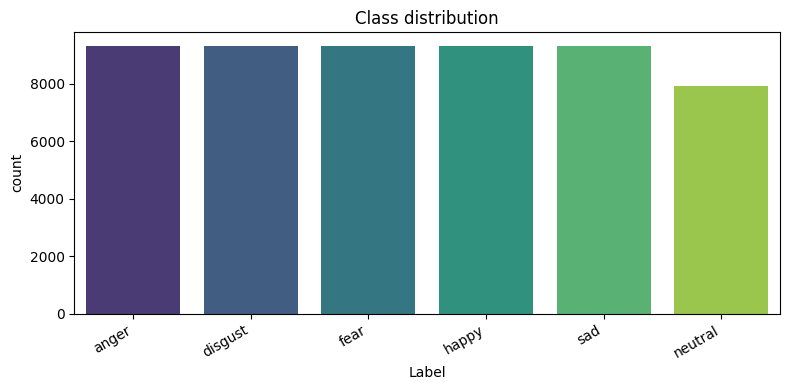

In [49]:
plt.figure(figsize=(8, 4))
order = y_label.value_counts().index.tolist()
sns.countplot(data=pd.DataFrame({"Label": y_label}), x="Label", order=order, palette="viridis")
plt.title("Class distribution")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


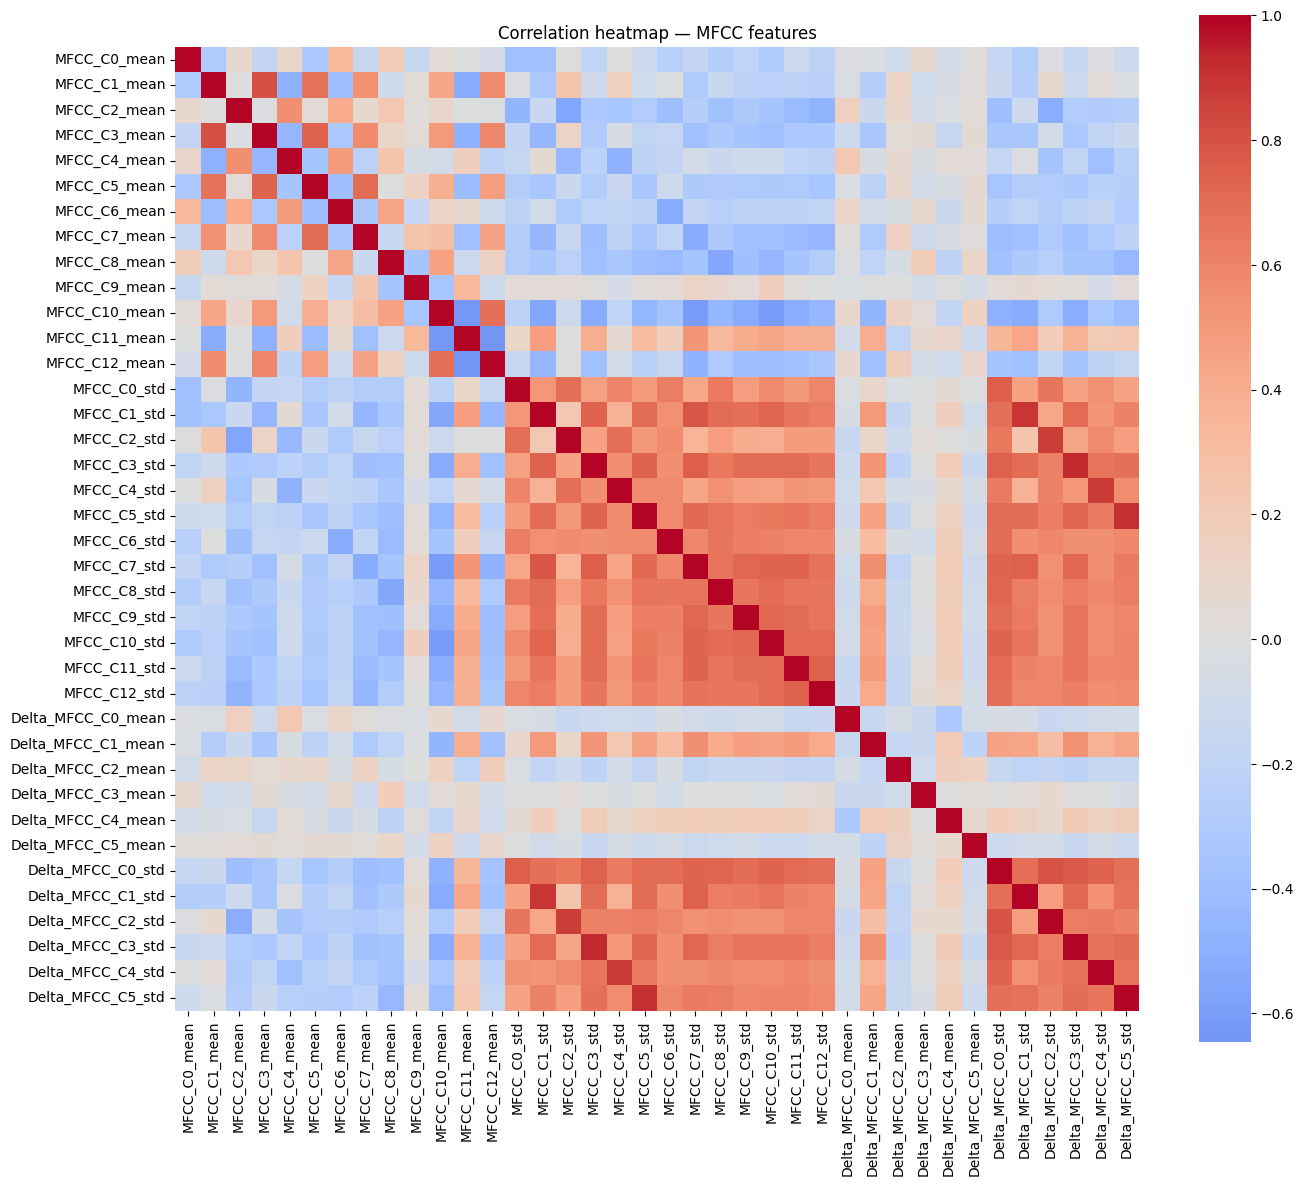

In [50]:
mfcc_cols = [c for c in FEATURE_COLS if "MFCC" in c]
cm = X[mfcc_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap — MFCC features")
plt.tight_layout()
plt.show()


In [51]:
le = LabelEncoder()
y = le.fit_transform(y_label)

print("label_id -> label_name:")
for i, name in enumerate(le.classes_):
    print(f"  {i} -> {name}")

X_train, X_test, y_train, y_test = train_test_split(
    X.values,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print("Train:", X_train.shape, "Test:", X_test.shape)


label_id -> label_name:
  0 -> anger
  1 -> disgust
  2 -> fear
  3 -> happy
  4 -> neutral
  5 -> sad
Train: (43588, 48) Test: (10897, 48)


In [52]:
CV_SPLITS = 5
RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def objective(trial):
    # ⚠️ FIX: truyền biến vào bên trong function
    global X_train, y_train, cv

    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 150, 250),
        max_depth=trial.suggest_int("max_depth", 15, 30),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        clf,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_weighted"
    )
    return scores.mean()


In [53]:
OPTUNA_TRIALS = 60
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

print("Best value (CV mean F1 weighted):", study.best_value)
print("Best params:", study.best_params)
best_params = study.best_params.copy()

[I 2026-05-27 14:26:25,281] A new study created in memory with name: no-name-4eb21a18-4431-4be5-b1fe-857bcd004f72
Best trial: 0. Best value: 0.803135:   2%|▏         | 1/60 [00:08<07:55,  8.06s/it]

[I 2026-05-27 14:26:33,345] Trial 0 finished with value: 0.803134522930919 and parameters: {'n_estimators': 187, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.803134522930919.


Best trial: 0. Best value: 0.803135:   3%|▎         | 2/60 [00:14<07:00,  7.25s/it]

[I 2026-05-27 14:26:40,027] Trial 1 finished with value: 0.7897818994987359 and parameters: {'n_estimators': 165, 'max_depth': 17, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.803134522930919.


Best trial: 0. Best value: 0.803135:   5%|▌         | 3/60 [00:28<09:49, 10.35s/it]

...

[I 2026-05-27 14:43:59,395] Trial 57 finished with value: 0.8188651687624207 and parameters: {'n_estimators': 250, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 43 with value: 0.8190917664636885.


Best trial: 43. Best value: 0.819092:  98%|█████████▊| 59/60 [17:42<00:12, 12.34s/it]

[I 2026-05-27 14:44:07,645] Trial 58 finished with value: 0.8169398293286866 and parameters: {'n_estimators': 166, 'max_depth': 28, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 43 with value: 0.8190917664636885.


Best trial: 43. Best value: 0.819092: 100%|██████████| 60/60 [17:51<00:00, 17.85s/it]

[I 2026-05-27 14:44:16,396] Trial 59 finished with value: 0.8160555442793569 and parameters: {'n_estimators': 183, 'max_depth': 26, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 43 with value: 0.8190917664636885.
Best value (CV mean F1 weighted): 0.8190917664636885
Best params: {'n_estimators': 244, 'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1}


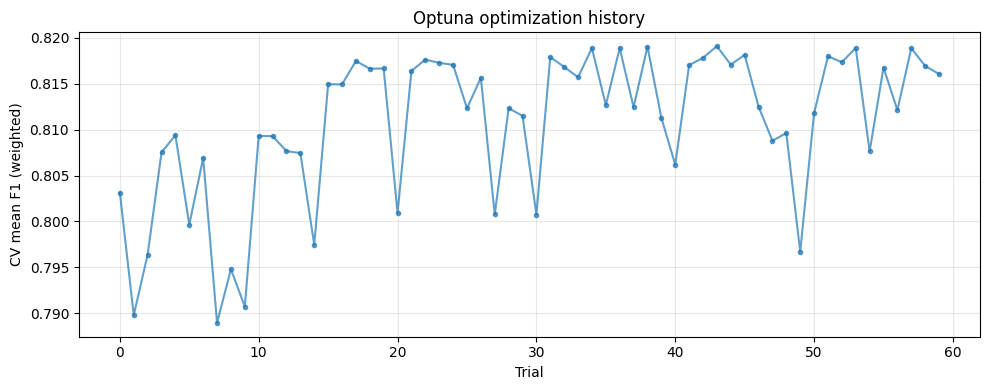

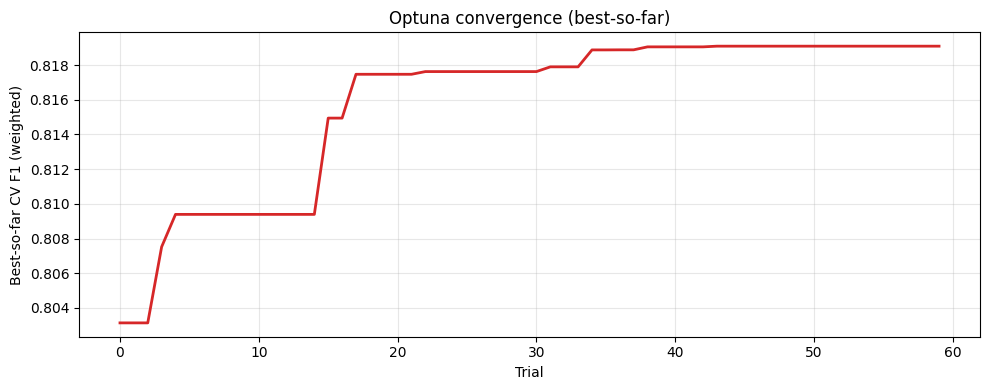

In [54]:
df_hist = study.trials_dataframe()
df_hist = df_hist.sort_values("number")

plt.figure(figsize=(10, 4))
plt.plot(df_hist["number"], df_hist["value"], marker="o", ms=3, alpha=0.7)
plt.xlabel("Trial")
plt.ylabel("CV mean F1 (weighted)")
plt.title("Optuna optimization history")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(df_hist["number"], df_hist["value"].cummax(), color="tab:red", lw=2)
plt.xlabel("Trial")
plt.ylabel("Best-so-far CV F1 (weighted)")
plt.title("Optuna convergence (best-so-far)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [55]:
bootstrap_value = best_params.get("bootstrap", True)

final_params = {
    "n_estimators": best_params.get("n_estimators", 200),
    "max_depth": best_params.get("max_depth", None),
    "max_features": best_params.get("max_features", "sqrt"),
    "min_samples_split": best_params.get("min_samples_split", 2),
    "min_samples_leaf": best_params.get("min_samples_leaf", 1),
    "bootstrap": bootstrap_value,
    "class_weight": best_params.get("class_weight", None),
    "oob_score": bootstrap_value,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}
# OOB only valid when bootstrap=True (RF.md)
final_params["oob_score"] = bool(best_params.get("bootstrap", True))

rf_final = RandomForestClassifier(**final_params)
rf_final.fit(X_train, y_train)
print("Fitted. oob_score:", getattr(rf_final, "oob_score_", None))


Fitted. oob_score: 0.8230017435991557


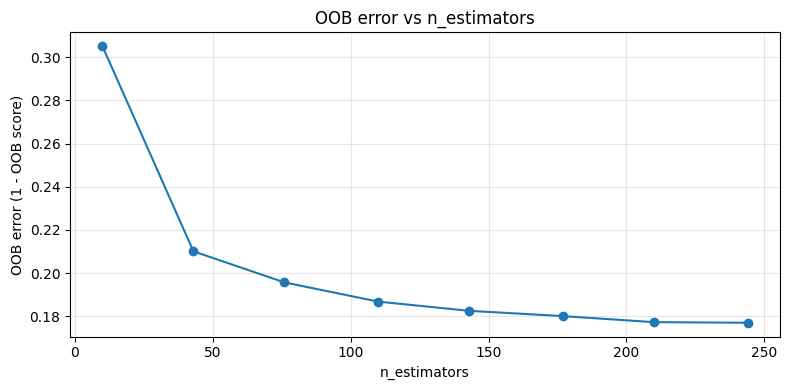

In [56]:
if not best_params.get("bootstrap", True):
    print("bootstrap=False -> OOB score not defined; skip OOB error curve.")
else:
    n_grid = np.linspace(10, int(best_params["n_estimators"]), 8, dtype=int)
    n_grid = np.unique(np.clip(n_grid, 10, None))
    oob_scores = []
    for n_est in n_grid:
        m = RandomForestClassifier(
            n_estimators=int(n_est),
            max_depth=best_params.get("max_depth", None),
            max_features=best_params.get("max_features", "sqrt"),
            min_samples_split=best_params.get("min_samples_split", 2),
            min_samples_leaf=best_params.get("min_samples_leaf", 1),
            bootstrap=True,
            oob_score=True,
            class_weight=best_params.get("class_weight", None),
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        m.fit(X_train, y_train)
        oob_scores.append(m.oob_score_)

    oob_err = 1.0 - np.array(oob_scores)
    plt.figure(figsize=(8, 4))
    plt.plot(n_grid, oob_err, marker="o")
    plt.xlabel("n_estimators")
    plt.ylabel("OOB error (1 - OOB score)")
    plt.title("OOB error vs n_estimators")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


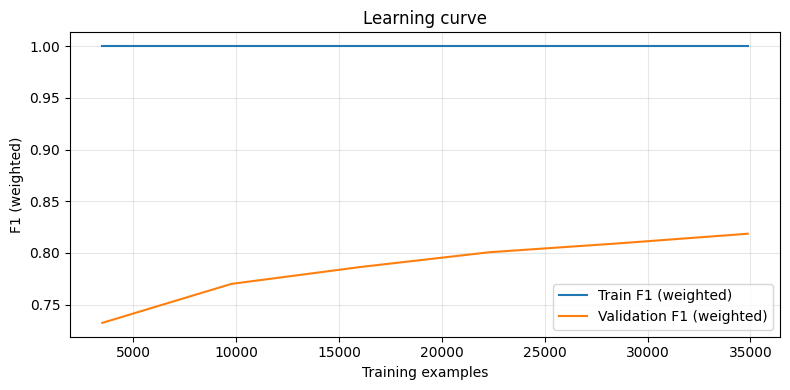

In [57]:
_lc_params = {k: v for k, v in final_params.items() if k != "oob_score"}
train_sizes, train_scores, valid_scores = learning_curve(
    RandomForestClassifier(**_lc_params),
    X_train,
    y_train,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="f1_weighted",
    shuffle=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, train_mean, label="Train F1 (weighted)")
plt.plot(train_sizes, valid_mean, label="Validation F1 (weighted)")
plt.xlabel("Training examples")
plt.ylabel("F1 (weighted)")
plt.title("Learning curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [58]:
y_pred = rf_final.predict(X_test)
y_pred_proba = rf_final.predict_proba(X_test)
print("y_pred shape:", y_pred.shape, "| proba:", y_pred_proba.shape)


y_pred shape: (10897,) | proba: (10897, 6)


In [59]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

f1w = f1_score(y_test, y_pred, average="weighted")
kappa = cohen_kappa_score(y_test, y_pred)
print(f"F1 (weighted): {f1w:.4f}")
print(f"Cohen kappa:   {kappa:.4f}")


              precision    recall  f1-score   support

       anger       0.94      0.89      0.91      1863
     disgust       0.80      0.82      0.81      1863
        fear       0.84      0.80      0.82      1863
       happy       0.77      0.84      0.80      1863
     neutral       0.78      0.80      0.79      1583
         sad       0.87      0.83      0.85      1862

    accuracy                           0.83     10897
   macro avg       0.83      0.83      0.83     10897
weighted avg       0.83      0.83      0.83     10897

F1 (weighted): 0.8319
Cohen kappa:   0.7973


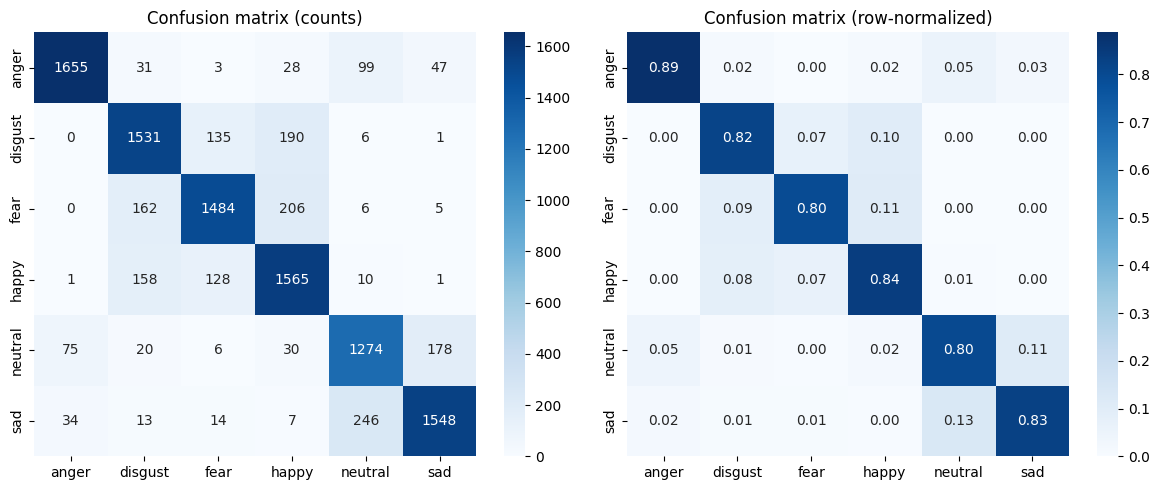

In [60]:
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0], xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title("Confusion matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=axes[1], xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title("Confusion matrix (row-normalized)")
plt.tight_layout()
plt.show()


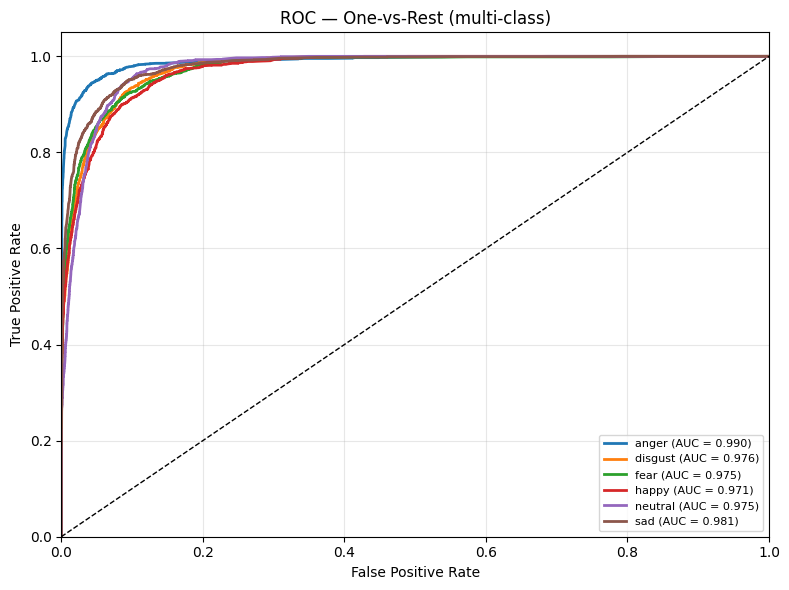

In [61]:
classes = le.classes_
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{classes[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — One-vs-Rest (multi-class)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


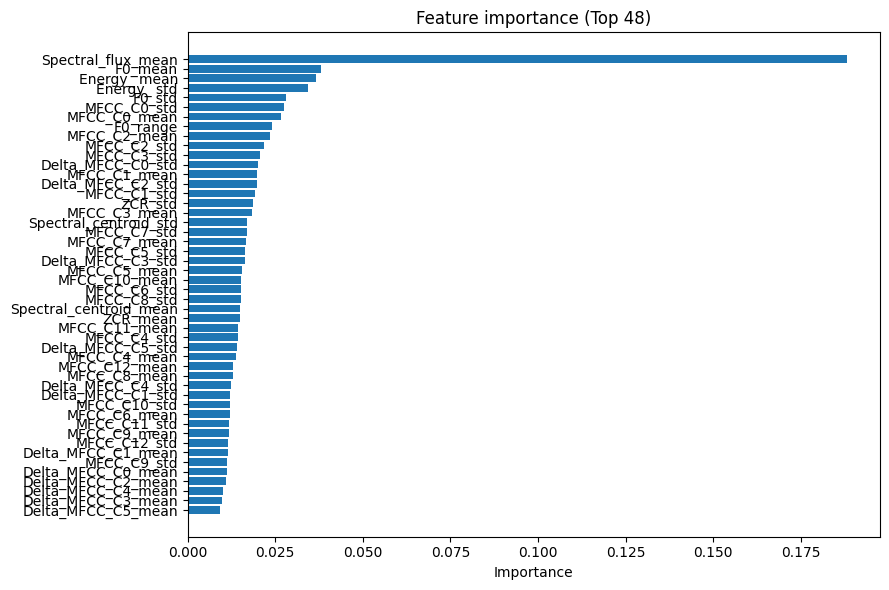

In [62]:
importances = rf_final.feature_importances_
idx = np.argsort(importances)[::-1][:48]
top_feats = [FEATURE_COLS[i] for i in idx]
top_vals = importances[idx]

plt.figure(figsize=(9, 6))
plt.barh(range(len(top_feats)), top_vals[::-1])
plt.yticks(range(len(top_feats)), top_feats[::-1])
plt.xlabel("Importance")
plt.title("Feature importance (Top 48)")
plt.tight_layout()
plt.show()


In [63]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
f1w = f1_score(y_test, y_pred, average="weighted")
macro_f1 = f1_score(y_test, y_pred, average="macro")
micro_f1 = f1_score(y_test, y_pred, average="micro")
kappa = cohen_kappa_score(y_test, y_pred)

summary = pd.DataFrame(
    {
        "metric": [
            "accuracy",
            "f1_weighted",
            "f1_macro",
            "f1_micro",
            "cohen_kappa",
            "optuna_best_cv_f1",
            "test_size",
            "n_train",
            "n_test",
        ],
        "value": [
            acc,
            f1w,
            macro_f1,
            micro_f1,
            kappa,
            study.best_value,
            TEST_SIZE,
            len(y_train),
            len(y_test),
        ],
    }
)
print(summary.to_string(index=False))


           metric        value
         accuracy     0.831146
      f1_weighted     0.831877
         f1_macro     0.830837
         f1_micro     0.831146
      cohen_kappa     0.797275
optuna_best_cv_f1     0.819092
        test_size     0.200000
          n_train 43588.000000
           n_test 10897.000000
